# Modelos de Regresion: Mas alla de la linea recta

**Curso III -- Bloque 1: Aprendizaje Supervisado**

En este notebook vamos a explorar cuatro grandes temas que extienden lo que ya sabemos de regresion lineal simple y multiple:

1. **Regularizacion**: Ridge, Lasso y Elastic Net.
2. **Random Forest y XGBoost** aplicados a problemas de regresion.
3. **Feature Engineering**: transformaciones, interacciones y variables polinomicas.
4. **Seleccion de variables**: como quedarnos solo con las que aportan.

**Prerrequisito**: se asume que ya conoces la regresion lineal simple (una variable) y multiple (varias variables). Partimos de ahi.

---

## 0. Preparacion del entorno

Importamos las librerias que vamos a usar a lo largo de todo el notebook. Si alguna no esta instalada, puedes instalarla con `pip install nombre_libreria`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Los datos: California Housing

Vamos a usar un dataset clasico de sklearn: precios de viviendas en California. Cada fila representa un grupo de viviendas (un "bloque censal") y queremos predecir el **precio mediano** de las viviendas en ese bloque.

Este dataset tiene 8 variables predictoras y mas de 20,000 observaciones, lo cual lo hace ideal para experimentar con distintos modelos de regresion.

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


Las variables son:

- **MedInc**: ingreso mediano de los hogares del bloque (en decenas de miles de USD).
- **HouseAge**: edad mediana de las viviendas.
- **AveRooms**: promedio de habitaciones por vivienda.
- **AveBedrms**: promedio de dormitorios por vivienda.
- **Population**: poblacion del bloque.
- **AveOccup**: promedio de ocupantes por vivienda.
- **Latitude** y **Longitude**: ubicacion geografica.
- **MedHouseVal**: precio mediano de la vivienda (lo que queremos predecir, en cientos de miles de USD).

## 2. Division de datos: entrenamiento y prueba

Antes de hacer cualquier cosa, separamos los datos en dos conjuntos:
- **Entrenamiento (80%)**: con estos datos el modelo aprende.
- **Prueba (20%)**: con estos datos evaluamos que tan bien generaliza el modelo a datos que nunca ha visto.

Esto es fundamental para detectar si un modelo esta memorizando en lugar de aprendiendo (overfitting).

In [4]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((16512, 8), (4128, 8))

## 3. Modelo base: Regresion Lineal Clasica (OLS)

Empezamos con el modelo que ya conocemos. Esto nos da un punto de referencia contra el cual comparar todos los demas modelos.

La regresion lineal clasica (OLS = Ordinary Least Squares) busca los coeficientes que minimizan la suma de los errores al cuadrado, sin ningun tipo de restriccion adicional.

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

pd.DataFrame({
    "Metrica": ["MAE", "RMSE", "R2"],
    "Valor": [round(mae_lr, 4), round(rmse_lr, 4), round(r2_lr, 4)]
})

,Metrica,Valor
0,MAE,0.5332
1,RMSE,0.7456
2,R2,0.5758


Estos numeros son nuestro punto de partida. Cualquier modelo nuevo que probemos deberia intentar mejorar estas metricas:

- **MAE (Mean Absolute Error)**: en promedio, el modelo se equivoca por esta cantidad (en cientos de miles de USD).
- **RMSE (Root Mean Squared Error)**: similar al MAE pero penaliza mas los errores grandes.
- **R2**: que porcentaje de la variabilidad del precio logra explicar el modelo. Un R2 de 0.60 significa que el modelo explica el 60% de la variacion en los precios.

---

## 4. Regularizacion: Ridge, Lasso y Elastic Net

### Por que necesitamos regularizacion?

La regresion lineal clasica tiene un problema: cuando hay muchas variables (o variables correlacionadas entre si), los coeficientes pueden volverse muy grandes e inestables. El modelo se ajusta demasiado a los datos de entrenamiento (overfitting) y generaliza mal a datos nuevos.

La regularizacion agrega una **penalizacion** a la funcion de costo para evitar que los coeficientes crezcan sin control. Es como ponerle un "freno" al modelo.

**Muy importante**: antes de aplicar regularizacion, las variables deben estar en la misma escala. Si una variable va de 0 a 1 y otra de 0 a 100,000, la penalizacion afectara injustamente a la segunda. Por eso usamos `StandardScaler`.

In [6]:
# Estandarizamos las variables (media=0, desviacion estandar=1)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

Nota importante sobre `fit_transform` vs `transform`:
- En entrenamiento usamos `fit_transform`: calcula la media y desviacion estandar, y luego transforma.
- En prueba usamos solo `transform`: usa la media y desviacion del entrenamiento (no del test). Esto evita "fugas de informacion" del conjunto de prueba.

### 4.1 Ridge Regression (L2)

Ridge agrega como penalizacion la **suma de los cuadrados** de los coeficientes:

$$\text{Minimizar: } \sum(y_i - \hat{y}_i)^2 + \alpha \sum \beta_j^2$$

Esto hace que todos los coeficientes se encojan hacia cero, pero **ninguno llega a ser exactamente cero**. Ridge es especialmente util cuando hay multicolinealidad (variables correlacionadas entre si).

El parametro `alpha` controla la fuerza de la penalizacion. Vamos a probar varios valores.

In [7]:
# Probamos varios valores de alpha
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

resultados_ridge = []
for a in alphas:
    modelo = Ridge(alpha=a)
    modelo.fit(X_train_sc, y_train)
    y_pred = modelo.predict(X_test_sc)

    resultados_ridge.append({
        "alpha": a,
        "MAE": round(mean_absolute_error(y_test, y_pred), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        "R2": round(r2_score(y_test, y_pred), 4)
    })

pd.DataFrame(resultados_ridge)

,alpha,MAE,RMSE,R2
0,0.01,0.5332,0.7456,0.5758
1,0.10,0.5332,0.7456,0.5758
2,1.00,0.5332,0.7456,0.5758
3,10.00,0.5331,0.7453,0.5761
4,100.00,0.5330,0.7438,0.5778


Observa como al aumentar alpha, el modelo se vuelve mas restrictivo. Con alphas muy pequenos, Ridge se comporta casi igual que OLS. Con alphas muy grandes, los coeficientes se encojen tanto que el modelo pierde capacidad predictiva.

Veamos como cambian los coeficientes con distintos niveles de regularizacion:

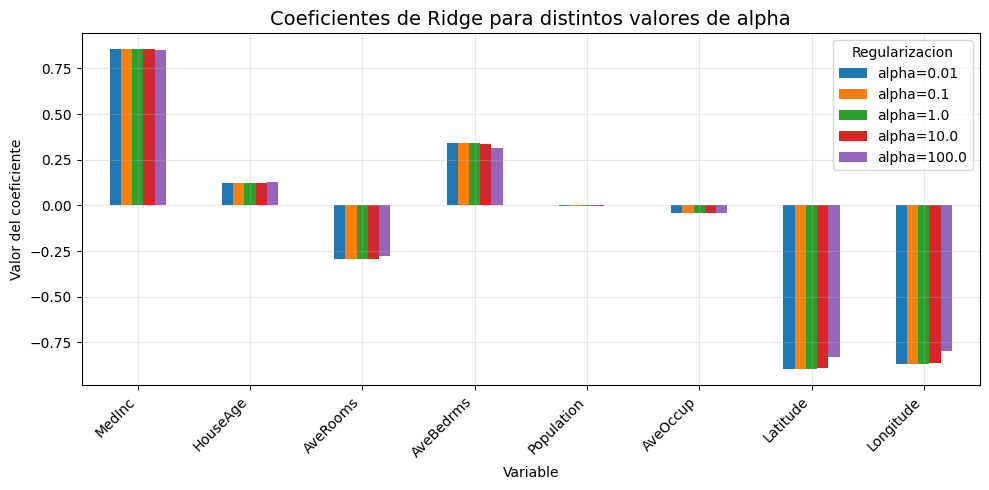

In [8]:
coefs_por_alpha = {}
for a in [0.01, 0.1, 1.0, 10.0, 100.0]:
    modelo = Ridge(alpha=a)
    modelo.fit(X_train_sc, y_train)
    coefs_por_alpha[f"alpha={a}"] = modelo.coef_

coefs_df = pd.DataFrame(coefs_por_alpha, index=X.columns)

fig, ax = plt.subplots(figsize=(10, 5))
coefs_df.plot(kind="bar", ax=ax)
ax.set_title("Coeficientes de Ridge para distintos valores de alpha", fontsize=14)
ax.set_ylabel("Valor del coeficiente")
ax.set_xlabel("Variable")
ax.legend(title="Regularizacion")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

La grafica muestra claramente como, a medida que alpha crece, los coeficientes se van encogiendo hacia cero. Pero ninguno llega a ser exactamente cero: Ridge **no elimina variables**, solo reduce su influencia.

---

### 4.2 Lasso Regression (L1)

Lasso agrega como penalizacion la **suma de los valores absolutos** de los coeficientes:

$$\text{Minimizar: } \sum(y_i - \hat{y}_i)^2 + \alpha \sum |\beta_j|$$

La gran diferencia con Ridge es que Lasso **puede hacer que algunos coeficientes sean exactamente cero**. Es decir, Lasso no solo regulariza, sino que tambien **selecciona variables** automaticamente.

In [9]:
resultados_lasso = []
for a in alphas:
    modelo = Lasso(alpha=a, max_iter=10000)
    modelo.fit(X_train_sc, y_train)
    y_pred = modelo.predict(X_test_sc)
    n_coefs_cero = np.sum(modelo.coef_ == 0)

    resultados_lasso.append({
        "alpha": a,
        "MAE": round(mean_absolute_error(y_test, y_pred), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        "R2": round(r2_score(y_test, y_pred), 4),
        "Variables eliminadas": n_coefs_cero
    })

pd.DataFrame(resultados_lasso)

,alpha,MAE,RMSE,R2,Variables eliminadas
0,0.01,0.5353,0.7404,0.5816,1
1,0.10,0.6222,0.8244,0.4814,5
2,1.00,0.9061,1.1449,-0.0002,8
3,10.00,0.9061,1.1449,-0.0002,8
4,100.00,0.9061,1.1449,-0.0002,8


Observa la columna "Variables eliminadas": a medida que alpha crece, Lasso va poniendo mas coeficientes en exactamente cero. Con alpha=100, casi todas las variables son eliminadas y el modelo pierde demasiada informacion.

Veamos los coeficientes con un alpha moderado:

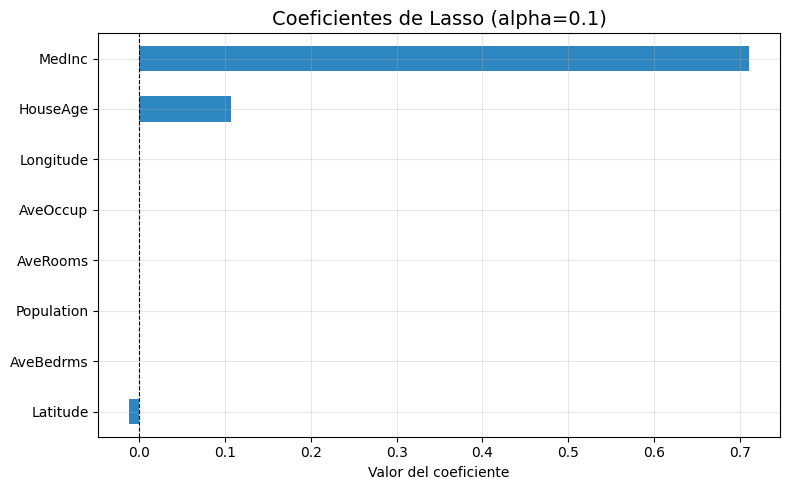

In [10]:
lasso_mod = Lasso(alpha=0.1, max_iter=10000)
lasso_mod.fit(X_train_sc, y_train)

coefs_lasso = pd.Series(lasso_mod.coef_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#2E86C1" if c != 0 else "#E74C3C" for c in coefs_lasso.values]
coefs_lasso.plot(kind="barh", color=colors, ax=ax)
ax.set_title("Coeficientes de Lasso (alpha=0.1)", fontsize=14)
ax.set_xlabel("Valor del coeficiente")
ax.axvline(x=0, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

Las barras rojas (si las hay) indican variables que Lasso elimino completamente. Las azules son las que el modelo considero relevantes. Esto es muy util cuando tienes muchas variables y quieres un modelo simple e interpretable.

---

### 4.3 Elastic Net (L1 + L2)

Elastic Net combina ambas penalizaciones:

$$\text{Minimizar: } \sum(y_i - \hat{y}_i)^2 + \alpha \left[ l1\_ratio \cdot \sum|\beta_j| + (1 - l1\_ratio) \cdot \sum\beta_j^2 \right]$$

- Si `l1_ratio = 1`: es Lasso puro.
- Si `l1_ratio = 0`: es Ridge puro.
- Valores intermedios combinan ambos.

Es especialmente util cuando hay grupos de variables correlacionadas: Lasso elegiria solo una del grupo, mientras que Elastic Net puede retener varias.

In [11]:
en = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
en.fit(X_train_sc, y_train)
y_pred_en = en.predict(X_test_sc)

mae_en = mean_absolute_error(y_test, y_pred_en)
rmse_en = np.sqrt(mean_squared_error(y_test, y_pred_en))
r2_en = r2_score(y_test, y_pred_en)
n_cero = np.sum(en.coef_ == 0)

pd.DataFrame({
    "Metrica": ["MAE", "RMSE", "R2", "Variables eliminadas"],
    "Valor": [round(mae_en, 4), round(rmse_en, 4), round(r2_en, 4), n_cero]
})

,Metrica,Valor
0,MAE,0.5970
1,RMSE,0.7974
2,R2,0.5148
3,Variables eliminadas,4.0000


### Validacion cruzada para elegir el mejor alpha

En lugar de adivinar que alpha es el mejor, podemos usar **validacion cruzada**. La idea es dividir los datos de entrenamiento en K partes (folds), entrenar con K-1 y evaluar en la restante, y repetir K veces. El promedio de los scores nos da una estimacion mas confiable del desempeno real.

In [12]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

# Ridge con CV
ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5)
ridge_cv.fit(X_train_sc, y_train)

# Lasso con CV
lasso_cv = LassoCV(alphas=[0.001, 0.01, 0.1, 1.0], cv=5, max_iter=10000)
lasso_cv.fit(X_train_sc, y_train)

# Elastic Net con CV
en_cv = ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], cv=5, max_iter=10000)
en_cv.fit(X_train_sc, y_train)

pd.DataFrame({
    "Modelo": ["Ridge", "Lasso", "Elastic Net"],
    "Mejor alpha": [ridge_cv.alpha_, round(lasso_cv.alpha_, 4), round(en_cv.alpha_, 4)],
    "R2 en test": [
        round(r2_score(y_test, ridge_cv.predict(X_test_sc)), 4),
        round(r2_score(y_test, lasso_cv.predict(X_test_sc)), 4),
        round(r2_score(y_test, en_cv.predict(X_test_sc)), 4),
    ]
})

,Modelo,Mejor alpha,R2 en test
0,Ridge,0.0100,0.5758
1,Lasso,0.0010,0.5769
2,Elastic Net,0.0009,0.5767


Los modelos con validacion cruzada seleccionan automaticamente el mejor alpha. Esto es mucho mas robusto que elegir un valor a mano.

---

## 5. Random Forest para regresion

Hasta ahora hemos trabajado con modelos lineales (que asumen que la relacion entre X e y es una linea recta, o al menos una combinacion lineal). Pero muchas relaciones en la realidad son **no lineales**.

Random Forest resuelve esto de una forma elegante:

1. Toma multiples muestras aleatorias de los datos (con reemplazo).
2. Entrena un arbol de decision en cada muestra.
3. Para predecir, promedia las predicciones de todos los arboles.

La clave es que cada arbol individual puede capturar relaciones no lineales, y al promediar muchos arboles, reducimos la varianza (el "ruido") de las predicciones.

**No necesitamos estandarizar las variables** para Random Forest. Los arboles trabajan con particiones, no con distancias ni magnitudes.

In [13]:
rf = RandomForestRegressor(
    n_estimators=200,     # numero de arboles
    max_depth=15,         # profundidad maxima de cada arbol
    min_samples_leaf=5,   # minimo de observaciones en cada hoja
    random_state=42,
    n_jobs=-1             # usar todos los nucleos del procesador
)

rf.fit(X_train, y_train)  # Nota: usamos X_train sin escalar
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

pd.DataFrame({
    "Metrica": ["MAE", "RMSE", "R2"],
    "Valor": [round(mae_rf, 4), round(rmse_rf, 4), round(r2_rf, 4)]
})

,Metrica,Valor
0,MAE,0.3338
1,RMSE,0.5145
2,R2,0.7980


Comparemos con la regresion lineal. Random Forest deberia capturar mejor las relaciones no lineales en los datos.

Una gran ventaja de Random Forest es que nos dice **que tan importante es cada variable**:

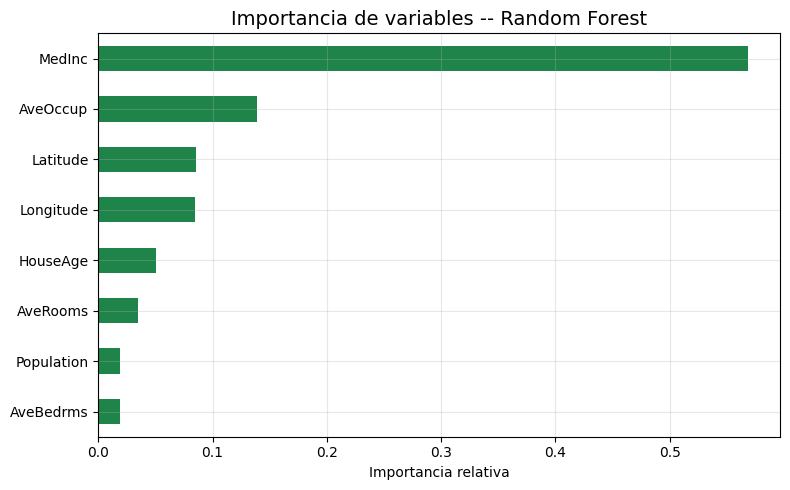

In [14]:
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importancias.plot(kind="barh", color="#1E8449", ax=ax)
ax.set_title("Importancia de variables -- Random Forest", fontsize=14)
ax.set_xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

Las variables con mayor importancia son las que mas contribuyen a reducir el error en las predicciones. Esto nos da una idea clara de cuales variables son las mas relevantes para predecir el precio.

---

## 6. XGBoost para regresion

XGBoost (eXtreme Gradient Boosting) es otro modelo basado en arboles, pero con una filosofia diferente a Random Forest:

- **Random Forest**: entrena muchos arboles en paralelo con muestras distintas y promedia.
- **XGBoost**: entrena arboles en secuencia, donde cada arbol nuevo intenta **corregir los errores del anterior**.

Esta estrategia (llamada "boosting") suele dar resultados muy precisos. Es el modelo que mas se usa en competencias de machine learning y en muchas aplicaciones industriales.

XGBoost tambien incluye **regularizacion interna**, lo cual ayuda a controlar el overfitting.

In [15]:
xgb_model = xgb.XGBRegressor(
    n_estimators=200,       # numero de arboles
    max_depth=6,            # profundidad maxima
    learning_rate=0.1,      # tasa de aprendizaje (que tan rapido aprende)
    subsample=0.8,          # fraccion de datos para cada arbol
    colsample_bytree=0.8,   # fraccion de variables para cada arbol
    reg_alpha=0.1,          # regularizacion L1 (tipo Lasso)
    reg_lambda=1.0,         # regularizacion L2 (tipo Ridge)
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)  # Tampoco necesita escalamiento
y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

pd.DataFrame({
    "Metrica": ["MAE", "RMSE", "R2"],
    "Valor": [round(mae_xgb, 4), round(rmse_xgb, 4), round(r2_xgb, 4)]
})

,Metrica,Valor
0,MAE,0.2986
1,RMSE,0.4518
2,R2,0.8442


Nota sobre los hiperparametros de XGBoost:

- `n_estimators`: cuantos arboles construir. Mas arboles = mas capacidad, pero tambien mas tiempo.
- `max_depth`: que tan "profundos" pueden ser los arboles. Arboles mas profundos capturan patrones mas complejos pero pueden sobreajustar.
- `learning_rate`: controla cuanto "aprende" cada arbol nuevo. Valores pequenos requieren mas arboles pero suelen generalizar mejor.
- `subsample` y `colsample_bytree`: fraccion de datos y variables usadas por cada arbol. Valores menores a 1.0 agregan aleatoriedad que ayuda a evitar overfitting.
- `reg_alpha` y `reg_lambda`: regularizacion L1 y L2 integrada en el modelo.

---

## 7. Feature Engineering

Feature engineering es el arte de **crear nuevas variables** a partir de las existentes para ayudar al modelo a capturar mejor los patrones en los datos. Es una de las habilidades mas valiosas en ciencia de datos.

Vamos a ver tres tecnicas fundamentales:

### 7.1 Transformaciones

Muchas variables en la vida real tienen distribuciones muy sesgadas (por ejemplo, ingresos o poblacion). Aplicar transformaciones como el logaritmo puede ayudar a normalizarlas y mejorar el desempeno de los modelos lineales.

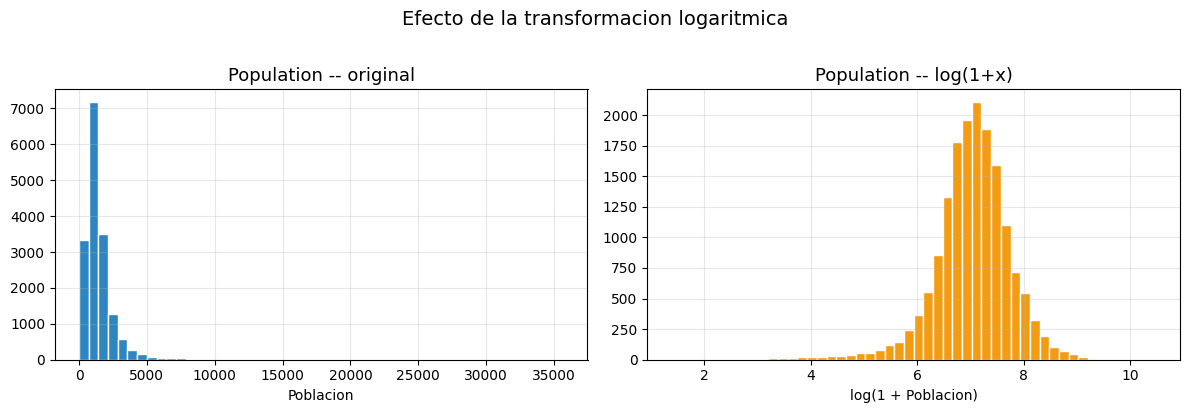

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X_train["Population"], bins=50, color="#2E86C1", edgecolor="white")
axes[0].set_title("Population -- original", fontsize=13)
axes[0].set_xlabel("Poblacion")

axes[1].hist(np.log1p(X_train["Population"]), bins=50, color="#F39C12", edgecolor="white")
axes[1].set_title("Population -- log(1+x)", fontsize=13)
axes[1].set_xlabel("log(1 + Poblacion)")

plt.suptitle("Efecto de la transformacion logaritmica", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

La transformacion `log(1+x)` (usamos 1+x para evitar problemas con el cero) convierte una distribucion muy sesgada hacia la derecha en una distribucion mas simetrica. Esto beneficia especialmente a los modelos lineales.

### 7.2 Interacciones

A veces, el efecto de una variable depende del valor de otra. Por ejemplo, el numero de habitaciones puede tener un efecto diferente en el precio dependiendo de la ubicacion. Capturamos esto creando una nueva variable que sea el **producto** de ambas.

In [17]:
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

# Interaccion: ingreso * habitaciones
X_train_fe["MedInc_x_AveRooms"] = X_train_fe["MedInc"] * X_train_fe["AveRooms"]

# Transformacion logaritmica de poblacion
X_train_fe["log_Population"] = np.log1p(X_train_fe["Population"])

# Lo mismo para el conjunto de prueba
X_test_fe["MedInc_x_AveRooms"] = X_test_fe["MedInc"] * X_test_fe["AveRooms"]
X_test_fe["log_Population"] = np.log1p(X_test_fe["Population"])

X_train_fe.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedInc_x_AveRooms,log_Population
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03,16.355553,7.741099
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16,17.055390,7.181592
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48,23.465777,6.820016
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11,7.775472,7.257708
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80,22.279222,6.774224


### 7.3 Variables polinomicas

Los modelos lineales asumen que la relacion entre X e y es una linea recta. Pero si la relacion es una curva (por ejemplo, una parabola), podemos capturarla agregando terminos polinomicos como x^2, x^3, etc.

La idea es que seguimos usando regresion lineal, pero las "variables" ahora incluyen potencias y combinaciones. El modelo sigue siendo lineal en los **coeficientes**, aunque no en las variables originales.

In [18]:
# Tomamos solo dos variables para visualizar el efecto
X_demo = X_train[["MedInc", "HouseAge"]].copy()

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_poly = poly.fit_transform(X_demo)

nombres_poly = poly.get_feature_names_out(["MedInc", "HouseAge"])
pd.DataFrame(X_poly[:5], columns=nombres_poly).round(2)

,MedInc,HouseAge,MedInc^2,MedInc HouseAge,HouseAge^2
0,3.26,33.0,10.62,107.57,1089.0
1,3.81,49.0,14.54,186.81,2401.0
2,4.16,4.0,17.27,16.63,16.0
3,1.94,36.0,3.77,69.93,1296.0
4,3.55,43.0,12.63,152.83,1849.0


Con `degree=2`, a partir de 2 variables originales (MedInc, HouseAge) obtenemos 5 variables: las dos originales, sus cuadrados (MedInc^2, HouseAge^2) y su interaccion (MedInc * HouseAge).

Veamos si estas nuevas variables mejoran la regresion lineal:

In [19]:
# Creamos variables polinomicas de grado 2 para TODAS las variables
poly_all = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly_all.fit_transform(X_train)
X_test_poly = poly_all.transform(X_test)

# Estandarizamos (necesario para modelos lineales con tantas variables)
scaler_poly = StandardScaler()
X_train_poly_sc = scaler_poly.fit_transform(X_train_poly)
X_test_poly_sc = scaler_poly.transform(X_test_poly)

# Regresion lineal con variables polinomicas
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly_sc, y_train)
y_pred_poly = lr_poly.predict(X_test_poly_sc)

# Ridge con variables polinomicas (para controlar overfitting)
ridge_poly = Ridge(alpha=10.0)
ridge_poly.fit(X_train_poly_sc, y_train)
y_pred_ridge_poly = ridge_poly.predict(X_test_poly_sc)

pd.DataFrame({
    "Modelo": ["OLS + polinomicos", "Ridge + polinomicos"],
    "MAE": [
        round(mean_absolute_error(y_test, y_pred_poly), 4),
        round(mean_absolute_error(y_test, y_pred_ridge_poly), 4),
    ],
    "RMSE": [
        round(np.sqrt(mean_squared_error(y_test, y_pred_poly)), 4),
        round(np.sqrt(mean_squared_error(y_test, y_pred_ridge_poly)), 4),
    ],
    "R2": [
        round(r2_score(y_test, y_pred_poly), 4),
        round(r2_score(y_test, y_pred_ridge_poly), 4),
    ],
    "Num. variables": [X_train_poly.shape[1], X_train_poly.shape[1]]
})

,Modelo,MAE,RMSE,R2,Num. variables
0,OLS + polinomicos,0.4670,0.6814,0.6457,44
1,Ridge + polinomicos,0.5012,0.7064,0.6192,44


Observa como al agregar variables polinomicas, la regresion lineal tiene muchas mas variables para trabajar. Pero tambien aumenta el riesgo de overfitting, por lo que Ridge (con regularizacion) suele funcionar mejor en este escenario.

---

## 8. Seleccion de variables

No todas las variables son utiles. Incluir variables irrelevantes puede:
- Agregar ruido al modelo.
- Hacerlo mas lento.
- Dificultar la interpretacion.

Vamos a ver tres metodos para identificar y conservar solo las variables mas importantes.

### 8.1 Importancia en Random Forest

Ya vimos esto brevemente. Random Forest calcula que tanto contribuye cada variable a reducir el error. Las variables con mayor importancia son las mas utiles para predecir.

In [20]:
importancias = pd.Series(
    rf.feature_importances_, index=X.columns
).sort_values(ascending=False)

importancias

,0
MedInc,0.568141
AveOccup,0.138512
Latitude,0.085589
Longitude,0.084923
HouseAge,0.050211
AveRooms,0.034894
Population,0.019023
AveBedrms,0.018706


### 8.2 Coeficientes de Lasso

Lasso tiene una ventaja unica: como parte de su regularizacion, automaticamente pone en cero los coeficientes de las variables menos importantes. Las variables que "sobreviven" (coeficiente distinto de cero) son las que Lasso considera mas relevantes.

In [21]:
lasso_sel = Lasso(alpha=0.01, max_iter=10000)
lasso_sel.fit(X_train_sc, y_train)

coefs_lasso_sel = pd.Series(lasso_sel.coef_, index=X.columns).sort_values(ascending=False)

variables_seleccionadas = coefs_lasso_sel[coefs_lasso_sel != 0].index.tolist()
variables_eliminadas = coefs_lasso_sel[coefs_lasso_sel == 0].index.tolist()

pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente Lasso": coefs_lasso_sel[X.columns].round(4).values,
    "Seleccionada": ["Si" if c != 0 else "No" for c in coefs_lasso_sel[X.columns].values]
})

,Variable,Coeficiente Lasso,Seleccionada
0,MedInc,0.8010,Si
1,HouseAge,0.1271,Si
2,AveRooms,-0.1628,Si
3,AveBedrms,0.2062,Si
4,Population,-0.0000,No
5,AveOccup,-0.0306,Si
6,Latitude,-0.7901,Si
7,Longitude,-0.7557,Si


### 8.3 Eliminacion recursiva de variables (RFE)

RFE (Recursive Feature Elimination) funciona asi:

1. Entrena el modelo con todas las variables.
2. Identifica la variable menos importante.
3. La elimina.
4. Repite hasta quedarse con el numero deseado de variables.

Es un metodo mas exhaustivo pero tambien mas costoso computacionalmente.

In [22]:
# Usamos Ridge como modelo base para RFE
rfe = RFE(
    estimator=Ridge(alpha=1.0),
    n_features_to_select=5,  # queremos quedarnos con 5 variables
    step=1                   # eliminar una variable por iteracion
)

rfe.fit(X_train_sc, y_train)

rfe_results = pd.DataFrame({
    "Variable": X.columns,
    "Ranking": rfe.ranking_,
    "Seleccionada": ["Si" if s else "No" for s in rfe.support_]
}).sort_values("Ranking")

rfe_results

,Variable,Ranking,Seleccionada
0,MedInc,1,Si
2,AveRooms,1,Si
3,AveBedrms,1,Si
7,Longitude,1,Si
6,Latitude,1,Si
1,HouseAge,2,No
5,AveOccup,3,No
4,Population,4,No


In [23]:
# Evaluamos el modelo solo con las variables seleccionadas por RFE
X_train_rfe = X_train_sc[:, rfe.support_]
X_test_rfe = X_test_sc[:, rfe.support_]

ridge_rfe = Ridge(alpha=1.0)
ridge_rfe.fit(X_train_rfe, y_train)
y_pred_rfe = ridge_rfe.predict(X_test_rfe)

pd.DataFrame({
    "Metrica": ["MAE", "RMSE", "R2", "Num. variables"],
    "Todas las variables": [round(mae_lr, 4), round(rmse_lr, 4), round(r2_lr, 4), 8],
    "Solo 5 variables (RFE)": [
        round(mean_absolute_error(y_test, y_pred_rfe), 4),
        round(np.sqrt(mean_squared_error(y_test, y_pred_rfe)), 4),
        round(r2_score(y_test, y_pred_rfe), 4),
        5
    ]
})

,Metrica,Todas las variables,Solo 5 variables (RFE)
0,MAE,0.5332,0.5392
1,RMSE,0.7456,0.7528
2,R2,0.5758,0.5675
3,Num. variables,8.0000,5.0000


Con RFE pasamos de 8 a 5 variables y el desempeno se mantiene muy similar. Esto confirma que no todas las variables originales eran necesarias.

---

## 9. Comparacion final de todos los modelos

Veamos todos los modelos que hemos entrenado, lado a lado:

In [24]:
comparacion = pd.DataFrame({
    "Modelo": [
        "Regresion Lineal (OLS)",
        "Ridge (mejor alpha por CV)",
        "Lasso (mejor alpha por CV)",
        "Elastic Net (CV)",
        "Ridge + Polinomicos",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        round(mae_lr, 4),
        round(mean_absolute_error(y_test, ridge_cv.predict(X_test_sc)), 4),
        round(mean_absolute_error(y_test, lasso_cv.predict(X_test_sc)), 4),
        round(mean_absolute_error(y_test, en_cv.predict(X_test_sc)), 4),
        round(mean_absolute_error(y_test, y_pred_ridge_poly), 4),
        round(mae_rf, 4),
        round(mae_xgb, 4),
    ],
    "RMSE": [
        round(rmse_lr, 4),
        round(np.sqrt(mean_squared_error(y_test, ridge_cv.predict(X_test_sc))), 4),
        round(np.sqrt(mean_squared_error(y_test, lasso_cv.predict(X_test_sc))), 4),
        round(np.sqrt(mean_squared_error(y_test, en_cv.predict(X_test_sc))), 4),
        round(np.sqrt(mean_squared_error(y_test, y_pred_ridge_poly)), 4),
        round(rmse_rf, 4),
        round(rmse_xgb, 4),
    ],
    "R2": [
        round(r2_lr, 4),
        round(r2_score(y_test, ridge_cv.predict(X_test_sc)), 4),
        round(r2_score(y_test, lasso_cv.predict(X_test_sc)), 4),
        round(r2_score(y_test, en_cv.predict(X_test_sc)), 4),
        round(r2_score(y_test, y_pred_ridge_poly), 4),
        round(r2_rf, 4),
        round(r2_xgb, 4),
    ]
})

comparacion.sort_values("R2", ascending=False)

,Modelo,MAE,RMSE,R2
6,XGBoost,0.2986,0.4518,0.8442
5,Random Forest,0.3338,0.5145,0.7980
4,Ridge + Polinomicos,0.5012,0.7064,0.6192
2,Lasso (mejor alpha por CV),0.5331,0.7446,0.5769
3,Elastic Net (CV),0.5331,0.7448,0.5767
1,Ridge (mejor alpha por CV),0.5332,0.7456,0.5758
0,Regresion Lineal (OLS),0.5332,0.7456,0.5758


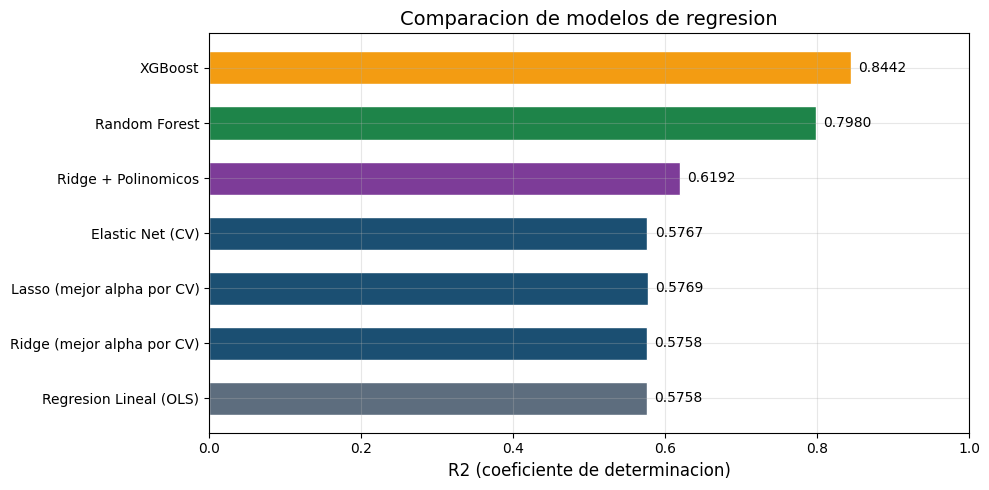

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

modelos = comparacion["Modelo"]
r2_vals = comparacion["R2"]
colores = ["#5D6D7E", "#1B4F72", "#1B4F72", "#1B4F72", "#7D3C98", "#1E8449", "#F39C12"]

bars = ax.barh(modelos, r2_vals, color=colores, edgecolor="white", height=0.6)
ax.set_xlabel("R2 (coeficiente de determinacion)", fontsize=12)
ax.set_title("Comparacion de modelos de regresion", fontsize=14)
ax.set_xlim(0, 1)

for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

## 10. Conclusiones

Recapitulando lo que hemos aprendido:

1. **Regularizacion** (Ridge, Lasso, Elastic Net) es una mejora directa sobre la regresion lineal clasica. Controla el overfitting y, en el caso de Lasso, tambien selecciona variables. Siempre requiere estandarizar las variables primero.

2. **Random Forest y XGBoost** son modelos basados en arboles que capturan relaciones no lineales sin necesidad de especificarlas manualmente. No requieren escalamiento de variables. Suelen dar mejor desempeno que los modelos lineales en datasets complejos.

3. **Feature Engineering** (transformaciones, interacciones, variables polinomicas) puede mejorar significativamente cualquier modelo. Es donde la creatividad y el conocimiento del dominio marcan la diferencia.

4. **Seleccion de variables** nos permite construir modelos mas simples, rapidos e interpretables. Los tres metodos principales son: importancia en Random Forest, coeficientes de Lasso, y eliminacion recursiva (RFE).

5. **Siempre comparar multiples modelos** y evaluar con validacion cruzada antes de elegir el modelo final.

---

**Siguiente paso**: en el notebook de practica, aplica estos conceptos a un dataset diferente y experimenta con distintas combinaciones de modelos y features.